# Exploratory Modeling

### Model Exploration vs Model Selection 
- Model selection is a rigorous notion in statistical learning.
- When should we test models on generalization or tune hyper-parameters?
    - If a model doesn't perform well on the training data, why look at its performance on testing data?
    - Also, the more "tests" we do, the more likely we are to make a wrong decision based of random chance: Multiple comparisons problem.
- Of course, model selection methods are used in exploring models.
    - However, the model should reasonable fit the data before we consider more advanced, costly techniques.
    - There is an arugment, though, that even exploring models is in effect a type of regularization... (Although, [this](https://en.wikipedia.org/wiki/Conditionality_principle) might be an interesing connection.)

### Overall take:
I feel that there is a misleading trend in the literature/tutorials/whatever: the train/test split is not mandatory, nor is it the holy-grail of model training/evaluation. Question every aspect of this, google/use AIs, and be skeptical.
- We will see the failure of our models without the train/test split.
- We don't want the best, we want a set of candidate which we might later use to infer a best model.
- Finally, machine learning is statistical learning. 


# Overview of notebook:

#### Goals:
1. Search for candidate  __well-performing interpratable models__
    - Likely won't involve a neural network
2. Search for a candidate __simplest most powerful models__
    - Likely will involve a neural network

#### Models to explore:
1. OLS regression on the avg counts ( log(avg counts) to keep it positive) 
    - categorical vs one-hot encoded varaibles
    - incorporating interaction terms? (these would be handmade nonlinear features)
    - Instead of $f(x)=x^T \beta$, use a non-linear approach: $f(x)=\text{NN}_\beta(x)$
2. Poisson regression
    - categorical vs one-hot encoded varaibles
    - incorporating more features
    - incorporating interaction terms again
    - Instead of $f(x)=x^T \beta$, use a non-linear approach: $f(x)=\text{NN}_\beta(x)$

#### Themes:
1. Start simple, build in features 
2. Number of model parameters vs number of samples.
    - A simple measure of model complexity, and a check for overfitting.
3. The loss function asummes a likelihood model.
4. The variance structure of the model vs. the data.
    - Distribution of model residuals
    - We know from the exploratory data analysis that the variance is heteroskedastic and much greater than the mean, so none of these models will be very accurate.
5. I am sloppy with how I denote dimensions and inner products.

### Further Exploration:
1. What about the autocorrelation structure?
    - Inspect the datas autocorrelation structure.
    - What types of models capture this?
2. Mixture models to handle the multimodality we observed in the count data.
3. One could build the model front-ends to handle data preprocessing, embedding/one-hot encoding. It would certainly clean up the pipeline.


### Exercises:

I've put some exercises/extensions below. It's probably best to give the notebook a first pass, then come back to the exercises if you're interested. 

1. We know coming into this the neither guassian nor poisson models will fit the variance structure of the data. 
    - Can we even tell if one of these models is better?
    - Can we tell when they are different (empircally or analytically)
    - Compare predictions for $\beta$.
2. Build in exact solution to linear regression.
    - Also, there is another way to formulate linear regression for this data using the MSE on the counts vs. their mean.
3. Try using an 'offset'
    - $\displaystyle \ln \lambda(t)=\ln(t)+X^T\beta$
2. Explore the use of other optimizers/gradient-based learning algorithms.
    - Sklearn uses L-BFGS to optimize their Poisson regressor.
3. Explore what the Gauss-Markov theorem has to say?

In [ ]:
# Install packages not available by default on Colab
# !pip install ucimlrepo --quiet

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time

import torch, torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import PoissonRegressor

from sklearn.metrics import r2_score, mean_squared_error
import scipy.stats as stats

from ucimlrepo import fetch_ucirepo, list_available_datasets

# fetch dataset 
bike_sharing = fetch_ucirepo(id=275) 

In [2]:
# data (as pandas dataframes) 
X = bike_sharing.data.features 
y = bike_sharing.data.targets 

df = pd.concat([X,y], axis=1)
print(f'df shape: {df.shape}')
print('List of features')
print(df.columns.tolist())

df shape: (17379, 14)
List of features
['dteday', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'cnt']


# Linear Regression (MSE) on the average counts

Let's begin by looking at counts vs (hour, day):
$$
\begin{align*}
    \lambda &= \bar{y} \\
    \log\lambda &= X^T \beta \\
    \text{or} \hspace{.2cm} \lambda &= \exp(X^T \beta)
\end{align*}
$$
- Modeling $\lambda=\exp X^T \beta$ ensures the average count stays positive.
- Hour and Day are 'categorical' by default - they enter as ordinary time would.Thus, we have
$$
\begin{align*}
\ln \lambda &= X^T \beta = \beta_0 + \beta_1\,\text{hour} + \beta_2 \, \text{day} \\
\leadsto \lambda &\sim e^{\# \, \text{hour}+ \#\,\text{day}}
\end{align*}
$$
    - This is not what we see. 
- One-hot encoding: 
    - Map $\{0,1,...,n\} \mapsto \{e_0,e_1,...,e_n\}$ where $[e_i]_j = \delta_{ij}$. 
    - These are the standard basis vectors of $\mathbb{R}^{n+1}$.
    - Now, each hour is it's own dimension, which corresponds to it's own column in the feature matrix. The same thing happens for the day.
$$
\begin{align*}
\ln \lambda &= X^T \beta = \beta_0 + \sum_{i=0}^{23}\beta_{1+i}\,\text{hour}_{i} + \sum_{i=0}^6 \beta_{24+i} \, \text{day}_i
\end{align*}
$$

We can use Pytroch to implement the linear function $f(x)$ where
$$
\begin{align*}
    f(x) &= X^T\beta \sim x^T\beta+\beta_0 \\
    NN_{\beta}(X) &= X^T \beta
\end{align*}
$$
This is an affine transformation of $X$ - the standard linear layer of a neural network. Sklearn also has a LinearRegression which you could use for comparisons.

Importantly, we will be using a mean-squared-error (MSE) loss between the empirical log-avg-counts from the data and the predicited log-avg-counts given by the output of our network, $NN_{\beta}(X) = X^T \beta$.
$$
\begin{align*}
    L(\beta) &= \sum_{i=1}^n \, \frac{1}{2}\left( \log\bar{y}^{(i)} - \beta^T x^{(i)}\right)^2 \\
    &= \sum_{i=1}^n \, \frac{1}{2}\left( \log\bar{y}^{(i)} - NN(x^{(i)})\right)^2 \\
    &= \text{MSELoss}(Y, NN_{\beta}(X))
\end{align*}
$$
The last line mirrors our PyTorch implenetation which can handle vector, matrix, tensor algebra for us, efficiently.

#### __Remarks:__
<!-- - We are doing standard gradient descent, not stochastic gradient desecent which involves randomly partitioning the training data into batches and moving through the batches within a training loop. -->
- Linear regression as formed doesn't respect the count nature of the data - linear regression assumes continuous data.
- We aren't doing stochastic batch learning. The original goal was to only use gradient descent (GD), but Adam has been seriously outperforming GD.
- We aren't doing the train/test split. We will look for other markers of model performance.

In [43]:
class AffineTransform(nn.Module):
    '''
    Transforms the input using an affine transformation - matrix product plus bias.
    Allows for a simple implementation of linear regression using PyTorch:
    '''
    def __init__(self, input_dim):
        super(AffineTransform, self).__init__()
        self.input_dim = input_dim

        self.linear = nn.Linear(in_features=self.input_dim, out_features=1, bias=True)

    def forward(self, x):
        x = self.linear(x)
        return x

In [44]:
## Compute the average counts with one-hot encoded features
## Keep only the hour and day for now

# Compute the average counts for fixed and day
avg_counts_df = df.groupby(['hr', 'weekday'])['cnt'].mean().reset_index()
X_avg = avg_counts_df[['hr', 'weekday']]
y_avg = avg_counts_df[['cnt']]

# One-hot encode the hr and weekday columns - categorical to dummy variables
# Drop first dummy variable since the full set is linearly dependenet (if not monday to saturday, then it is sunday)
X_avg_onehot = pd.get_dummies(X_avg, columns=['hr', 'weekday'], drop_first=True, dtype=float)
X_avg_onehot.head()


,hr_1,hr_2,hr_3,hr_4,hr_5,hr_6,hr_7,hr_8,hr_9,hr_10,...,hr_20,hr_21,hr_22,hr_23,weekday_1,weekday_2,weekday_3,weekday_4,weekday_5,weekday_6
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [45]:
## shapes of features and target
## Notice the reduction is sample-size: 17379 to 168=24*7
print(X_avg.shape)
print(X_avg_onehot.shape)
print(y_avg.shape)

# build 'training' sets
X_train = torch.tensor(X_avg_onehot.values, dtype=torch.float32)
y_train = torch.tensor(y_avg.values, dtype=torch.float32).view(-1, 1)
y_train = torch.log(y_train + 1e-8) # We are modeling the log avg_cnt, add epsilon to avoid log(0)

(168, 2)
(168, 29)
(168, 1)


In [46]:
input_dim = X_avg_onehot.shape[1]
model = AffineTransform(input_dim)

optimizer = optim.Adam(model.parameters(), lr=1e-4)
loss_function = nn.MSELoss()


n_epochs = int(5e4)
for epoch in range(n_epochs):
    model.train()
    optimizer.zero_grad()
    pred_log_rate = model(X_train)
    loss = loss_function(pred_log_rate, y_train)
    loss.backward()
    optimizer.step()
    if epoch % 1000 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")
        # print(f"\rEpoch {epoch}, Loss: {loss.item():.4f}", end='')

Epoch 0, Loss: 24.2533
Epoch 1000, Loss: 21.6871
Epoch 2000, Loss: 19.3297
Epoch 3000, Loss: 17.1561
Epoch 4000, Loss: 15.1496
Epoch 5000, Loss: 13.3005
Epoch 6000, Loss: 11.6026
Epoch 7000, Loss: 10.0519
Epoch 8000, Loss: 8.6447
Epoch 9000, Loss: 7.3764
Epoch 10000, Loss: 6.2401
Epoch 11000, Loss: 5.2298
Epoch 12000, Loss: 4.3414
Epoch 13000, Loss: 3.5684
Epoch 14000, Loss: 2.9054
Epoch 15000, Loss: 2.3479
Epoch 16000, Loss: 1.8906
Epoch 17000, Loss: 1.5278
Epoch 18000, Loss: 1.2509
Epoch 19000, Loss: 1.0472
Epoch 20000, Loss: 0.9017
Epoch 21000, Loss: 0.7962
Epoch 22000, Loss: 0.7117
Epoch 23000, Loss: 0.6374
Epoch 24000, Loss: 0.5706
Epoch 25000, Loss: 0.5119
Epoch 26000, Loss: 0.4616
Epoch 27000, Loss: 0.4193
Epoch 28000, Loss: 0.3839
Epoch 29000, Loss: 0.3541
Epoch 30000, Loss: 0.3289
Epoch 31000, Loss: 0.3076
Epoch 32000, Loss: 0.2895
Epoch 33000, Loss: 0.2740
Epoch 34000, Loss: 0.2608
Epoch 35000, Loss: 0.2496
Epoch 36000, Loss: 0.2401
Epoch 37000, Loss: 0.2323
Epoch 38000, Loss

In [47]:
## Predict the means for each (hour,day)
## This is just the training data/features
with torch.no_grad():
    log_rate_preds = model(X_train).numpy().flatten()

## Add a 'predicted mean' column to the average_counts dataframe
avg_counts_df['linear_mean'] = np.exp(log_rate_preds)

## Utilize pivots for easy plotting (index=x-axis, values=y-axis, columns=curve/plot-index)
pivot_pred = avg_counts_df.pivot(index='hr', columns='weekday', values='linear_mean')
pivot_actual = avg_counts_df.pivot(index='hr', columns='weekday', values='cnt')

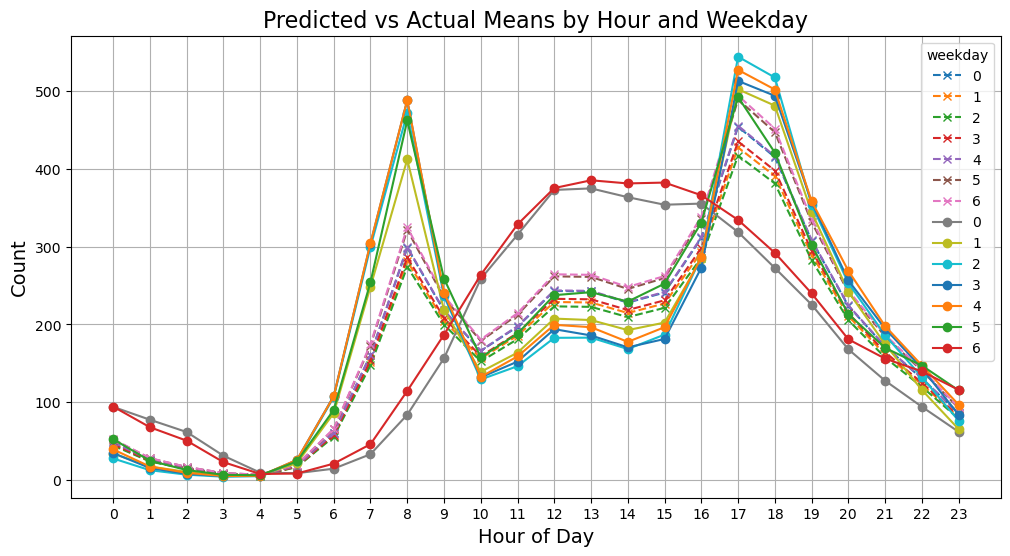

Samples: 168, Parameters: 30, Ratio: 5.60


In [49]:
fig, ax = plt.subplots(figsize=(12,6))

# Plot predicted counts (dashed lines)
pivot_pred.plot(ax=ax, marker='x', linestyle='--')

# Plot actual counts (solid lines)
pivot_actual.plot(ax=ax, marker='o', linestyle='-')

ax.set_title('Predicted vs Actual Means by Hour and Weekday', fontsize=16)
ax.set_xlabel('Hour of Day', fontsize=14)
ax.set_ylabel('Count', fontsize=14)
ax.set_xticks(range(24))
ax.grid(True)
# ax.legend(['Predicted', 'Actual'])
plt.show()

total_params = sum(p.numel() for p in model.parameters())
n_samples = X_train.shape[0]
print(f"Samples: {n_samples}, Parameters: {total_params}, Ratio: {n_samples/total_params:.2f}")

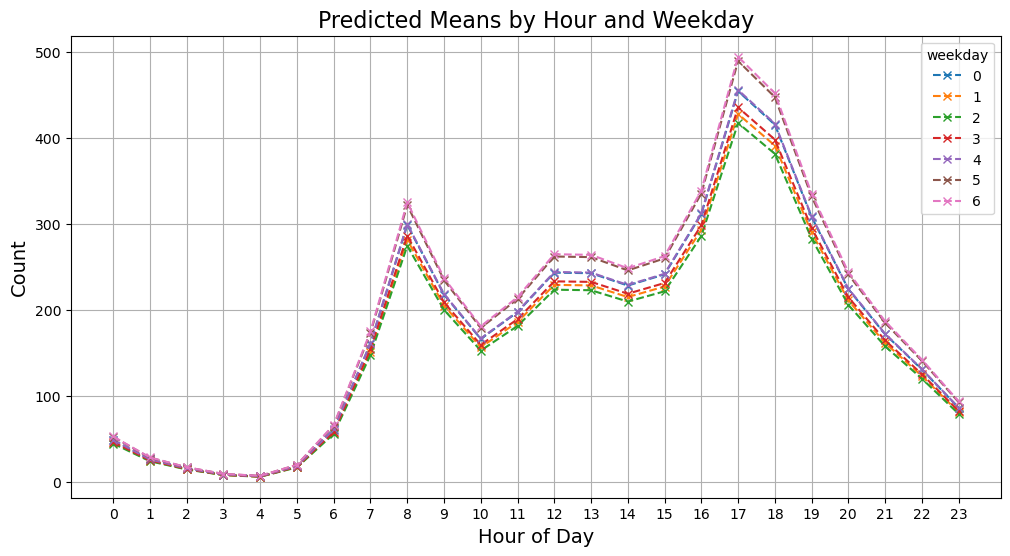

Samples: 168, Parameters: 30, Ratio: 5.60


In [51]:
fig, ax = plt.subplots(figsize=(12,6))

# Plot predicted counts (dashed lines)
pivot_pred.plot(ax=ax, marker='x', linestyle='--')

# Plot actual counts (solid lines)
# pivot_actual.plot(ax=ax, marker='o', linestyle='-')

ax.set_title('Predicted Means by Hour and Weekday', fontsize=16)
ax.set_xlabel('Hour of Day', fontsize=14)
ax.set_ylabel('Count', fontsize=14)
ax.set_xticks(range(24))
ax.grid(True)
# ax.legend(['Predicted', 'Actual'])
plt.show()

total_params = sum(p.numel() for p in model.parameters())
n_samples = X_train.shape[0]
print(f"Samples: {n_samples}, Parameters: {total_params}, Ratio: {n_samples/total_params:.2f}")

### Discussion

1. Can we augment the features to give a better fit for weekends?
    - Feature Engineering:
        - __More features:__ Would adding in the workingday feature linearly help?
        - __Interacting features:__ a term of the form $\beta_{ij} \text{hour}_i \text{day}_j$ allows for each (hour,day) to have it own rate.
        - __'Disjoint' training:__ Could train a weekday model and weekend model seperately.
            - This likely is not the best thing to do....
         - __'Fully' nonlinear features:__ Add a hidden layer to the neural network
2. How well is the model capturing the data structure?
    - Distribution of residuals
    - Does this model capture the variance of the data?
        - No! The data itself is exhibits variance>>mean, and is higher for larger rates/means.
        - Gaussian likelihood enforces variance=constant


# Inspecting model performance

The modeling assumpting for linear regression is 
$$
\begin{align*}
\log \lambda &= X^T \beta + \epsilon \hspace{.2cm} \text{ where $\epsilon \sim \mathcal{N}(0,\sigma^2)$}
\end{align*}
$$
__If this model is correct__, then the residuals, the differences of truth from model, 
$$ r_i = \log\, \bar{y}^{(i)} - x^{(i),T} \beta
$$
- Should then be Gaussian as well.
- Should be center about its mean/expectation $\mathbb{E}[\log \bar{y}^{(i)}]=\log \lambda$ 
- A plot of the residuals $r_i$ vs. the predictions $\log \bar{y}^{(i)}$ is then a helpful tool.


However, if the model is incorrect, or misspecified, the residuals will follow some other distribution. We can get a sense of effect by supposing the "true" model can be described via $\gamma$:
$$
\begin{align*}
\log \lambda &= X^T \beta + \gamma \\
            &= X^T \beta + \epsilon + \left(\gamma - \epsilon\right)
\end{align*}
$$
where $\delta = \gamma - \epsilon$ modifies the distribution of the misspecified model's residuals. It also likely baises our estimator. Of course, this is probably grossly oversimplified.
- I haven't dug into this data/analysis, but I felt it would still be good for discussion.
- A QQ plot (quartile-quartile plot) should be linear if our model is correct. Look this up.

Log MSE: 0.2064, Log R²: 0.8807
Raw MSE: 4902.67, Raw R²: 0.7654


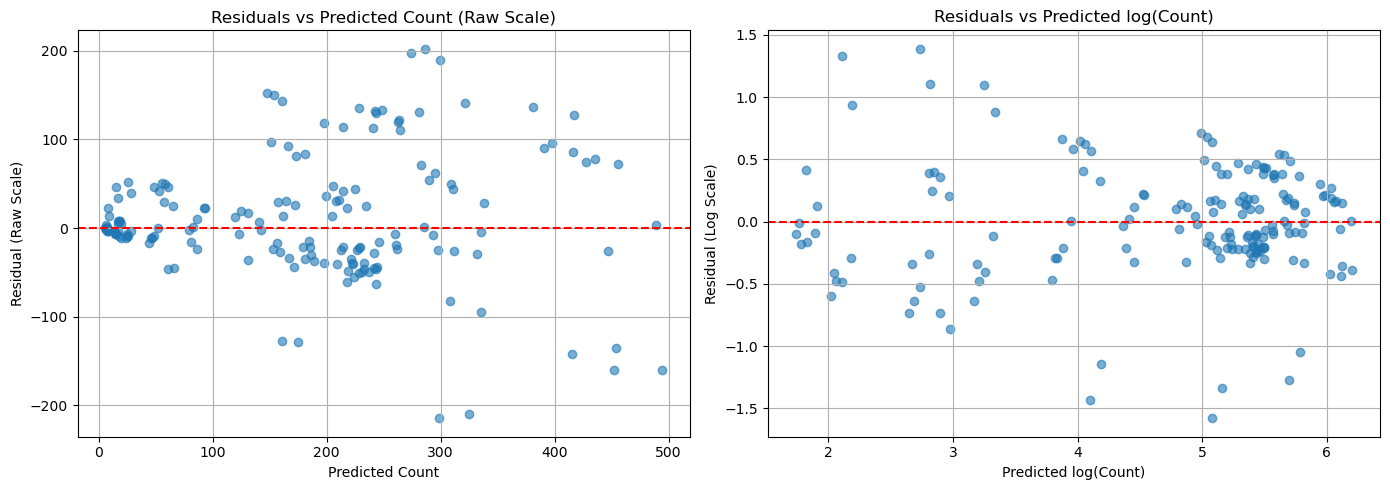

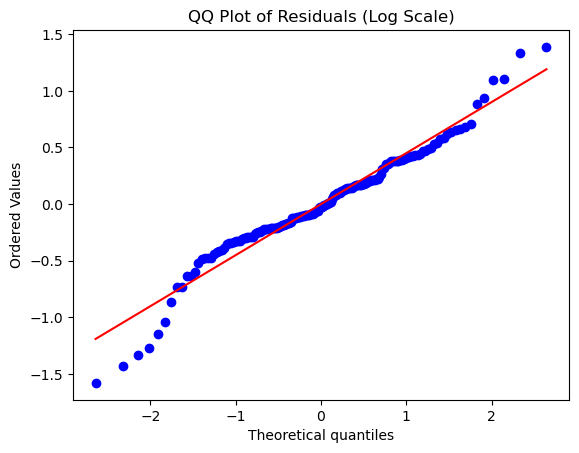

In [ ]:
# Pull aligned true values and predicted values
y_true = avg_counts_df['cnt'].values ## These are actually the average counts
y_pred = avg_counts_df['linear_mean'].values

# Log-transform
y_true_log = np.log(y_true + 1e-8)
y_pred_log = np.log(y_pred + 1e-8)

# Residuals
residuals_raw = y_true - y_pred
residuals = y_true_log - y_pred_log

# Metrics
mse = mean_squared_error(y_true_log, y_pred_log)
r2 = r2_score(y_true_log, y_pred_log)
mse_raw = mean_squared_error(y_true, y_pred)
r2_raw = r2_score(y_true, y_pred)

print(f"MSE: {mse:.4f}, R²: {r2:.4f}")
print(f"Raw MSE: {mse_raw:.2f}, Raw R²: {r2_raw:.4f}")

# Residual plots
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

axs[0].scatter(y_pred, residuals_raw, alpha=0.6)
axs[0].axhline(0, color='red', linestyle='--')
axs[0].set_title("Residuals vs Predicted Count (Raw Scale)")
axs[0].set_xlabel("Predicted Count")
axs[0].set_ylabel("Residual (Raw Scale)")
axs[0].grid(True)

axs[1].scatter(y_pred_log, residuals, alpha=0.6)
axs[1].axhline(0, color='red', linestyle='--')
axs[1].set_title("Residuals vs Predicted log(Count)")
axs[1].set_xlabel("Predicted log(Count)")
axs[1].set_ylabel("Residual (Log Scale)")
axs[1].grid(True)

plt.tight_layout()
plt.show()

# QQ plot for log-residuals
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("QQ Plot of Residuals (Log Scale)")
plt.show()


## Extensions:
1. Neural linear regression using a hidden-layer FF network
2. Exploring effect of interaction between hour and day

## Effect of a non-linear neural network model

In [10]:
class NonLinearTransform(nn.Module):
    def __init__(self, input_dim, hidden_size=16):
        super(NonLinearTransform, self).__init__()
        self.hidden_size = hidden_size
        self.linear1 = nn.Linear(input_dim, self.hidden_size)
        self.linear2 = nn.Linear(self.hidden_size, 1)

    def forward(self, x):
        x = F.relu(self.linear1(x))
        x = self.linear2(x)
        return x

In [11]:
input_dim = X_avg_onehot.shape[1]
model = NonLinearTransform(input_dim, hidden_size=10)

optimizer = optim.Adam(model.parameters(), lr=1e-4)
loss_function = nn.MSELoss()


n_epochs = int(2e4)
for epoch in range(n_epochs):
    model.train()
    optimizer.zero_grad()
    pred_rate = model(X_train)
    loss = loss_function(pred_rate, y_train)
    loss.backward()
    optimizer.step()
    if epoch % 1000 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")
        # print(f"\rEpoch {epoch}, Loss: {loss.item():.4f}", end='')

Epoch 0, Loss: 24.3335
Epoch 1000, Loss: 18.9282
Epoch 2000, Loss: 10.3043
Epoch 3000, Loss: 4.2345
Epoch 4000, Loss: 1.5598
Epoch 5000, Loss: 0.8278
Epoch 6000, Loss: 0.5674
Epoch 7000, Loss: 0.4345
Epoch 8000, Loss: 0.3431
Epoch 9000, Loss: 0.2659
Epoch 10000, Loss: 0.2038
Epoch 11000, Loss: 0.1588
Epoch 12000, Loss: 0.1190
Epoch 13000, Loss: 0.0871
Epoch 14000, Loss: 0.0636
Epoch 15000, Loss: 0.0473
Epoch 16000, Loss: 0.0355
Epoch 17000, Loss: 0.0257
Epoch 18000, Loss: 0.0184
Epoch 19000, Loss: 0.0118


In [12]:
## Predict the means for each (hour,day)
## This is just the training data/features
with torch.no_grad():
    preds = model(X_train).numpy().flatten()

## Add a 'predicted mean' column to the average_counts dataframe
avg_counts_df['nonlinear_mean'] = np.exp(preds)

## Utilize pivots for easy plotting (index=x-axis, values=y-axis, columns=curve/plot-index)
pivot_pred = avg_counts_df.pivot(index='hr', columns='weekday', values='nonlinear_mean')
pivot_actual = avg_counts_df.pivot(index='hr', columns='weekday', values='cnt')

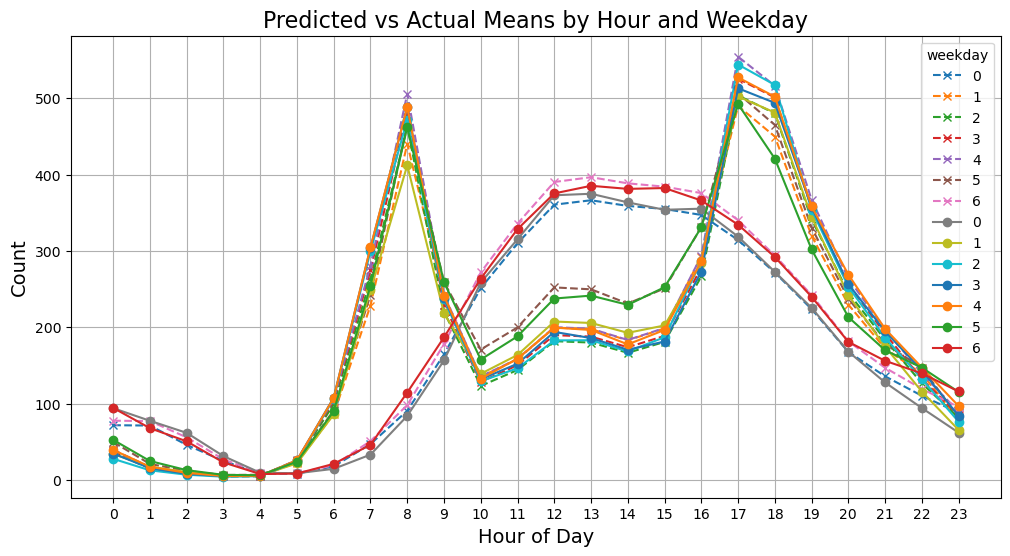

Samples: 168, Parameters: 311, Ratio: 0.54


In [13]:
fig, ax = plt.subplots(figsize=(12,6))

# Plot predicted counts (dashed lines)
pivot_pred.plot(ax=ax, marker='x', linestyle='--')

# Plot actual counts (solid lines)
pivot_actual.plot(ax=ax, marker='o', linestyle='-')

ax.set_title('Predicted vs Actual Means by Hour and Weekday', fontsize=16)
ax.set_xlabel('Hour of Day', fontsize=14)
ax.set_ylabel('Count', fontsize=14)
ax.set_xticks(range(24))
ax.grid(True)
# ax.legend(['Predicted', 'Actual'])
plt.show()

total_params = sum(p.numel() for p in model.parameters())
n_samples = X_train.shape[0]
print(f"Samples: {n_samples}, Parameters: {total_params}, Ratio: {n_samples/total_params:.2f}")

Log MSE: 0.2064, Log R²: 0.8807
Raw MSE: 4902.67, Raw R²: 0.7654


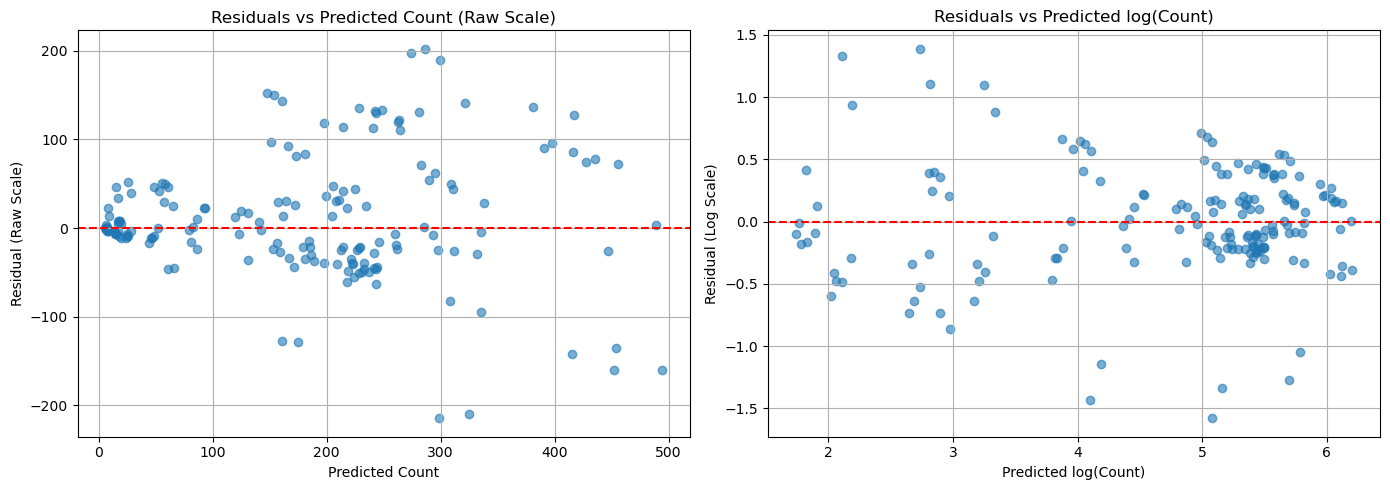

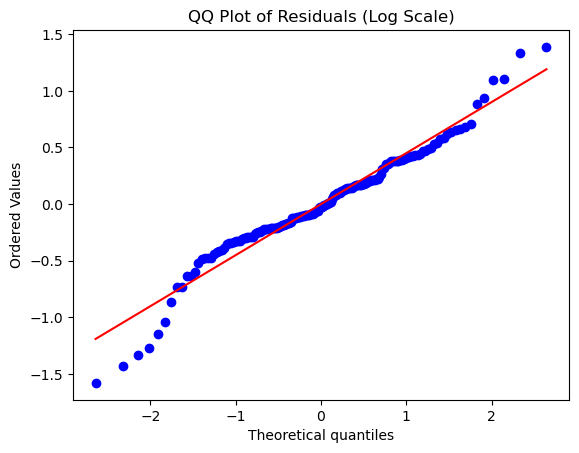

In [ ]:
# Pull aligned true values and predicted values
y_true = avg_counts_df['cnt'].values ## These are actually the average counts
y_pred = avg_counts_df['linear_mean'].values

# Log-transform
y_true_log = np.log(y_true + 1e-8)
y_pred_log = np.log(y_pred + 1e-8)

# Residuals
residuals_raw = y_true - y_pred
residuals = y_true_log - y_pred_log

# Metrics
mse = mean_squared_error(y_true_log, y_pred_log)
r2 = r2_score(y_true_log, y_pred_log)
mse_raw = mean_squared_error(y_true, y_pred)
r2_raw = r2_score(y_true, y_pred)

print(f"MSE: {mse:.4f}, R²: {r2:.4f}")
print(f"Raw MSE: {mse_raw:.2f}, Raw R²: {r2_raw:.4f}")

# Residual plots
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

axs[0].scatter(y_pred, residuals_raw, alpha=0.6)
axs[0].axhline(0, color='red', linestyle='--')
axs[0].set_title("Residuals vs Predicted Count (Raw Scale)")
axs[0].set_xlabel("Predicted Count")
axs[0].set_ylabel("Residual (Raw Scale)")
axs[0].grid(True)

axs[1].scatter(y_pred_log, residuals, alpha=0.6)
axs[1].axhline(0, color='red', linestyle='--')
axs[1].set_title("Residuals vs Predicted log(Count)")
axs[1].set_xlabel("Predicted log(Count)")
axs[1].set_ylabel("Residual (Log Scale)")
axs[1].grid(True)

plt.tight_layout()
plt.show()

# QQ plot for log-residuals
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("QQ Plot of Residuals (Log Scale)")
plt.show()


## Effect of interaction terms:

### Can we understand some of the non-linearity the FFNN learned?

Here instead of doing a linear fit over one-hot encoded hours and days, we use only an interaction effect of the form $\beta_{ij}\,\text{hour}_i*\text{day}_j$. This way, the model will determine a rate for each (hour,day) combination.
$$
\begin{align}
    X &\sim \text{hour}_i \times \text{day}_j \\
    X^T \beta &= \sum_{i,j} \beta_{ij}\text{hour}_i \times \text{day}_j \\
    \lambda &= \exp X^T \beta
\end{align}
$$
- I apologize for the gross code for construct the interactions.
- This may actually have an exact solution.
- See if adding in the linear hour and day featues helps?
- Could do higher order terms - multinomial in hour and day.


In [15]:
X = df[[ 'hr', 'weekday']]
y = df['cnt']

X_onehot = pd.get_dummies(X, columns=['hr', 'weekday'], drop_first=True, dtype=float)

In [16]:
hr_cols = [col for col in X_onehot.columns if col.startswith('hr_')]
weekday_cols = [col for col in X_onehot.columns if col.startswith('weekday_')]

# Create interaction terms efficiently
interaction_cols = []
interaction_data = []

for h in hr_cols:
    for d in weekday_cols:
        interaction_cols.append(f'{h}__{d}')
        interaction_data.append(X_onehot[h].values * X_onehot[d].values)

# Create interaction DataFrame all at once
interaction_terms = pd.DataFrame(np.array(interaction_data).T, columns=interaction_cols, index=X_onehot.index)

# Combine with original features
X = pd.concat([X_onehot, interaction_terms], axis=1)
# X = interaction_terms

X_train = torch.tensor(X.values, dtype=torch.float32)
y_train = torch.tensor(y.values, dtype=torch.float32).view(-1, 1)
y_train = torch.log(y_train + 1e-8) # We are modeling the log avg_cnt, add epsilon to 

In [17]:
input_dim = X.shape[1]
model = AffineTransform(input_dim)
optimizer = optim.Adam(model.parameters(), lr=1e-4)
loss_function = nn.MSELoss()


n_epochs = int(5e4)
for epoch in range(n_epochs):
    model.train()
    optimizer.zero_grad()
    pred_rate = model(X_train)
    loss = loss_function(pred_rate, y_train)
    loss.backward()
    optimizer.step()
    if epoch % 1000 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")
        # print(f"\rEpoch {epoch}, Loss: {loss.item():.4f}", end='')

Epoch 0, Loss: 21.8269
Epoch 1000, Loss: 18.7915
Epoch 2000, Loss: 16.1054
Epoch 3000, Loss: 13.7204
Epoch 4000, Loss: 11.6035
Epoch 5000, Loss: 9.7299
Epoch 6000, Loss: 8.0809
Epoch 7000, Loss: 6.6434
Epoch 8000, Loss: 5.4067
Epoch 9000, Loss: 4.3598
Epoch 10000, Loss: 3.4914
Epoch 11000, Loss: 2.7914
Epoch 12000, Loss: 2.2483
Epoch 13000, Loss: 1.8464
Epoch 14000, Loss: 1.5647
Epoch 15000, Loss: 1.3761
Epoch 16000, Loss: 1.2490
Epoch 17000, Loss: 1.1534
Epoch 18000, Loss: 1.0683
Epoch 19000, Loss: 0.9865
Epoch 20000, Loss: 0.9092
Epoch 21000, Loss: 0.8381
Epoch 22000, Loss: 0.7739
Epoch 23000, Loss: 0.7165
Epoch 24000, Loss: 0.6659
Epoch 25000, Loss: 0.6222
Epoch 26000, Loss: 0.5851
Epoch 27000, Loss: 0.5542
Epoch 28000, Loss: 0.5290
Epoch 29000, Loss: 0.5087
Epoch 30000, Loss: 0.4927
Epoch 31000, Loss: 0.4801
Epoch 32000, Loss: 0.4701
Epoch 33000, Loss: 0.4618
Epoch 34000, Loss: 0.4549
Epoch 35000, Loss: 0.4493
Epoch 36000, Loss: 0.4448
Epoch 37000, Loss: 0.4414
Epoch 38000, Loss: 0

In [18]:
## This code block just compues the rate-predictions for each given hour and day
## It is oder code that I did not clean up...

rates = []

for day in range(0, 7):
    if day == 0:
        day_one_hot = [0] * 6
    else:
        day_one_hot = [1 if i == day else 0 for i in range(1, 7)]

    daily_rates = []

    for hour in range(0, 24):
        if hour == 0:
            hour_one_hot = [0] * 23
        else:
            hour_one_hot = [1 if i == hour else 0 for i in range(1, 24)]

        # Compute interaction terms
        interaction = []
        for h in hour_one_hot:
            for d in day_one_hot:
                interaction.append(h * d)

        # Final feature vector
        feature = np.array(hour_one_hot + day_one_hot + interaction).reshape(1, -1)
        feature = torch.tensor(feature,dtype=torch.float32)
        log_rate = model(feature).detach().numpy()
        rate = np.exp(log_rate)
        daily_rates.append(rate.squeeze())

    rates.append(daily_rates)


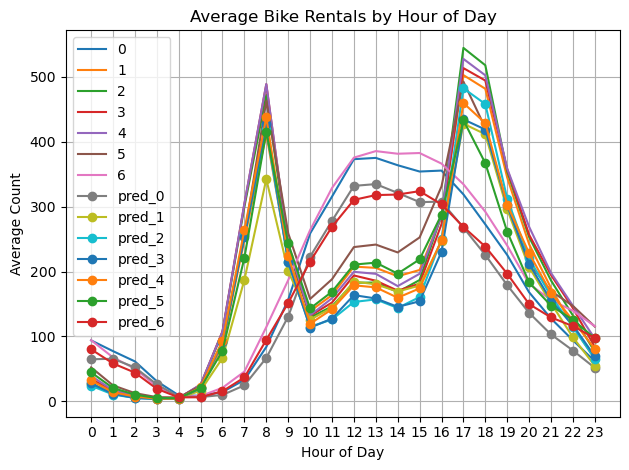

Samples: 17379, Parameters: 168, Ratio: 103.45


In [19]:
avg_count = df.groupby(['weekday','hr'])[['cnt']].mean().reset_index()
ax = avg_count.pivot(index='hr', columns='weekday', values='cnt').plot()

for i, daily_rates in enumerate(rates):
    plt.plot(range(24), daily_rates, marker='o', label = f'pred_{i}')

plt.xlabel('Hour of Day')
plt.ylabel('Average Count')
plt.title('Average Bike Rentals by Hour of Day')
plt.xticks(range(24))
plt.grid(True)
plt.tight_layout()
plt.legend()
plt.show()

total_params = sum(p.numel() for p in model.parameters())
n_samples = X.shape[0]
print(f"Samples: {n_samples}, Parameters: {total_params}, Ratio: {n_samples/total_params:.2f}")

# Poisson Regression

### $\ln \lambda = X^T \beta$ but with PoissonLoss

We now use the same expression for the log-rates, but instead use a different loss function which encodes our asummption of the likelihood! We now want to model a Poisson likelihood. 

Recall the likelihood and log-likelihood for the Poisson model which has $y \in \mathbb{N}$:
$$
\begin{align}
    p(y \mid \beta) &= \frac{\lambda^y}{y!} \exp(-\lambda) \\
    l(y \mid \beta) &= \log p(y \mid \beta) \\
    &= y^{(i)} \ln \lambda - \ln y^{(i)}! -\lambda
\end{align}
$$
where $\lambda$ depends on $\beta$ through our model asuumption. This model respect the discrete count nature of the data. Now given the data, $(X,y)$:
$$
\begin{align}
    l(y \mid \beta) &= \log \prod_{i=1}^n p(y^{(i)} \mid \beta) \\
    &= \sum_{i=1}^n \left( y^{(i)} \ln \lambda - \ln y^{(i)}! -\lambda \right) \\
    &= \sum_{i=1}^n \left( y^{(i)} \beta^T X^{(i)}  - \ln y^{(i)}! - \exp\{\beta^TX^{(i)}\} \right)
\end{align}
$$
- Note that for this loss/likelihood, we don't need to even compute the empirical rates/averages. The loss insteads needs to empirical counts, $y^{(i)}$.
- Just as for linear, we feed the feature matrix (one-hot encoding as before) to the network: $$NN_{\beta}(X) = X^T \beta$$ 
- Using 
$$\lambda=\exp X^T \beta = \exp \, NN_{\beta}(X)$$
 we can write the loss (a negative log-likelihood loss) in terms of targets and NN:
$$
\begin{align}
    L(\beta) &= - l(y \mid \beta)\\
    &= -\sum_{i=1}^n \left( y^{(i)} NN(x^{(i)})  - \ln y^{(i)}! - \exp \{NN(x^{(i)})\} \right) \\
    &= \sum_{i=1}^n \left( \exp \{NN(x^{(i)})\} - y^{(i)} NN(x^{(i)})\right) \\
    &\sim \text{predicted-rate} - \text{target}*\text{log-predicted-rate} \\
    &= \text{PoissonLoss}(NN(X), Y)
\end{align}
$$
where we suppress $\beta$ depenedence of $NN(x)$ for readability. In the middle line, we dropped the $\ln y^{(i)}!$ term since it is independent of $\beta$ and so does not affect optimzation.

### Remarks:

1. All of the feature engineering/selection ideas for the linear case will carry over to the Poisson case. The switch from linear to Poisson will take very little modification. (It essentially only requires us to change the loss function. If we build the data preprocessing into the model, the loss function would be the only change.)
2. The effect of one-hot encoding, interactions, and non-linear transforms on the rate prediction/behavior will be the same.
    <!-- - If we don't one-hot encode the hour and day, Poisson regression would still predict a rate which is exponential in the hour and day. The relation between the rate/mean and the features is unchanged. What's changed is the likelihood model, which is implied by loss function! -->
3. We begin again with the expression for the log-rate as below.
$$
\begin{align}
\ln \lambda &= X^T \beta = \beta_0 + \sum_{i=0}^{23}\beta_{1+i}\,\text{hour}_{i} + \sum_{i=0}^6 \beta_{24+i} \, \text{day}_i
\end{align}
$$
    - For those interested, the above form for the rate is equivalent to using a non-homogeneous Poisson process model for regression.

#### Preprocess the data (as before)

In [20]:
X = df[[ 'hr', 'weekday']]
# we will use the original y:
y = df['cnt']

X_onehot = pd.get_dummies(X, columns=['hr', 'weekday'], drop_first=True, dtype=float)

In [21]:
## shapes of features and target
print(X.shape)
print(X_onehot.shape)
print(y.shape)

# build 'training' sets
X_train = torch.tensor(X_onehot.values, dtype=torch.float32)
y_train = torch.tensor(y.values, dtype=torch.float32).view(-1, 1)

(17379, 2)
(17379, 29)
(17379,)


#### Define loss and training loop

Confirm that our homemade PoissonLoss is reproduced by PyTorch's function

In [22]:
## Define our custom Poisson Loss function
## PyTorch does offer a built in nn.PoissonLoss

def poisson_nll_loss(log_pred_rate, target):
    # pred_rate: predicted lambda (rate), target: observed counts
    # NN outputs the log-rate
    pred_rate = torch.exp(log_pred_rate)
    return torch.mean(pred_rate - target * torch.log(pred_rate + 1e-8))

In [23]:
input_dim = X_onehot.shape[1]
model = AffineTransform(input_dim)
# optimizer = optim.SGD(model.parameters(), lr=1e-4)
optimizer = optim.Adam(model.parameters(), lr=0.01)

loss_function = nn.PoissonNLLLoss(log_input=True) # torch can handle log-rate and/or rate
# loss_function = poisson_nll_loss

n_epochs = int(2e3)
for epoch in range(n_epochs):
    model.train()
    optimizer.zero_grad()
    log_pred_rate = model(X_train)
    pred_rate = torch.exp(log_pred_rate)
    loss = loss_function(log_pred_rate, y_train)
    loss.backward()
    optimizer.step()
    if epoch % 100 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")
        # print(f"\rEpoch {epoch}, Loss: {loss.item():.4f}", end='')

Epoch 0, Loss: 19.3735
Epoch 100, Loss: -501.8470
Epoch 200, Loss: -810.1370
Epoch 300, Loss: -831.9811
Epoch 400, Loss: -835.1767
Epoch 500, Loss: -837.8754
Epoch 600, Loss: -840.6143
Epoch 700, Loss: -843.2891
Epoch 800, Loss: -845.7773
Epoch 900, Loss: -847.9685
Epoch 1000, Loss: -849.7819
Epoch 1100, Loss: -851.1806
Epoch 1200, Loss: -852.1791
Epoch 1300, Loss: -852.8365
Epoch 1400, Loss: -853.2370
Epoch 1500, Loss: -853.4659
Epoch 1600, Loss: -853.5936
Epoch 1700, Loss: -853.6678
Epoch 1800, Loss: -853.7170
Epoch 1900, Loss: -853.7559


#### Predict the rates

In [24]:
## Predict the rates/mean for each (hour,day)
## Construct Hours_of_the_week dataframe to house the one-hot encoded labels
## Important: Hours_of_the_week and avg_counts_df should have the same ordering!!!

Hours_of_the_week = avg_counts_df[['hr', 'weekday']]
Hours_of_the_week = pd.get_dummies(Hours_of_the_week, columns=['hr', 'weekday'], drop_first=True, dtype=float)
Hours_of_the_week = torch.tensor(Hours_of_the_week.values, dtype=torch.float32)

with torch.no_grad():
    log_preds = model(Hours_of_the_week).numpy().flatten()
    preds = np.exp(log_preds)

avg_counts_df['poisson_mean'] = preds

#### Plot and Compare

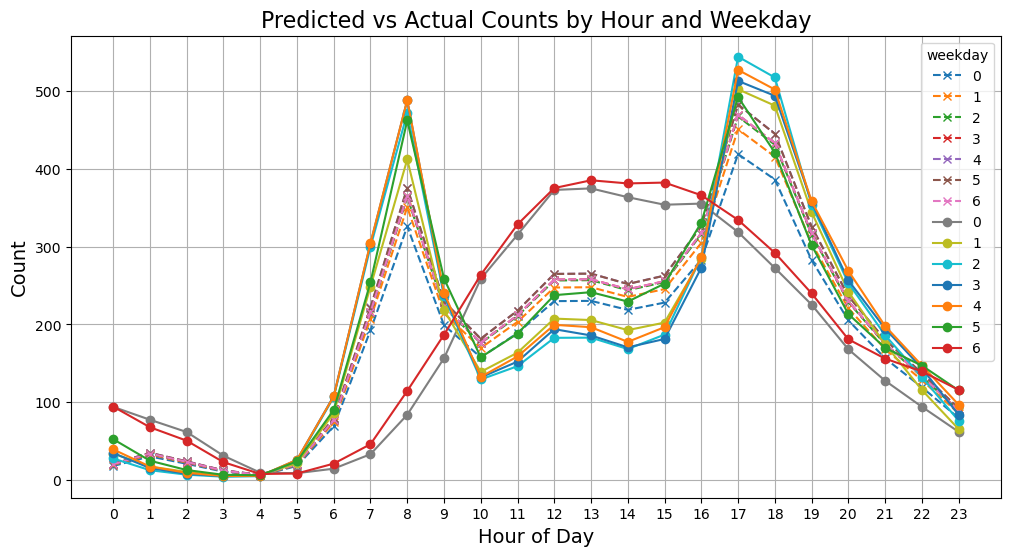

Samples: 17379, Parameters: 30, Ratio: 579.30


In [25]:
pivot_pred = avg_counts_df.pivot(index='hr', columns='weekday', values='poisson_mean')
pivot_actual = avg_counts_df.pivot(index='hr', columns='weekday', values='cnt')


fig, ax = plt.subplots(figsize=(12,6))

# Plot predicted counts (dashed lines)
pivot_pred.plot(ax=ax, marker='x', linestyle='--')

# Plot actual counts (solid lines)
pivot_actual.plot(ax=ax, marker='o', linestyle='-')

ax.set_title('Predicted vs Actual Counts by Hour and Weekday', fontsize=16)
ax.set_xlabel('Hour of Day', fontsize=14)
ax.set_ylabel('Count', fontsize=14)
ax.set_xticks(range(24))
ax.grid(True)
# ax.legend(['Predicted', 'Actual'])
plt.show()

total_params = sum(p.numel() for p in model.parameters())
n_samples = X_train.shape[0]
print(f"Samples: {n_samples}, Parameters: {total_params}, Ratio: {n_samples/total_params:.2f}")

## Discussion

1. Poisson regression has just has many parameters as linear regression; however, it is able to use the full dataset, 17379 samples, while linear used a reduced set of 168 samples - the empirical means for each (hour,day)
2. The fits alone don't allow us to discriminate the Poisson from Linear.
    - Question: do their results for $\beta$ differ?
2. Additionally, Poisson regression is still struggling with the weekends. We can use the same modifications as for linear regression:
    - Feature Engineering:
        - __More features:__ Would adding in the workingday feature linearly help?
        - __Interacting features:__ a term of the form $\beta_{ij} \text{hour}_i \text{day}_j$ allows for each (hour,day) to have it own rate.
        - __'Disjoint' training:__ Could train a weekday model and weekend model seperately.
            - This likely is not the best thing to do....
         - __'Fully' nonlinear features:__ Add a hidden layer to the neural network
4. Other aspects to inspect:
    - Distribution of residuals
    - Does this model capture the variance of the data?
        - No! The data itself is exhibits variance>>mean!
        - Poisson likelihood enforces variance=mean. While this does capture so of the heteroskedasticity (rate dependence of the variance :) ), it doesn't capture all of it.
    - The next natural extension is probably using what's known as Negative-Binomial regression. It allows for more control of the variance. This is not the only direction to go though. These might be interesting:
            - Heteroskedastic MSE
            - Gaussian NLL loss via [PyTorch](https://docs.pytorch.org/docs/stable/generated/torch.nn.GaussianNLLLoss.html)
            - heteroskedastic neural nets with variance heads
            - Gaussian process regression

## Extensions:
<!-- 1. Exploring effect of workingday feature. -->
2. Inspecting model performance for a Poisson likelihood.
3. Exploring effect of interaction between hour and day.
4. Neural Poisson regression using a hidden-layer FF network
5. __Bonus:__ Neural Poisson regression via an recurrent neural network for the time-corrlelation structure.

# Inspecting model performance

The modeling assumpting for Poisson regression is (I'm being a bit loose here)
$$
\begin{align*}
\log \lambda &= X^T \beta \sim \text{Poisson}(\lambda)
\end{align*}
$$

### Room for Exploration and Discussion

The behavior of the residuals is a bit different than for the Gaussian model case. For this example, we can use what are known are Pearson residuals.
$$
r_i^{(P)} = \frac{f_i-\hat{f}_i}{\text{Var}(\hat{f})}
$$

Now, if our model is correct, these residuals are the ones which will be Gaussian. 
- Again, I haven't dug into this data/analysis, but I felt it would still be good for discussion.
- Discuss the proper terms to appear in the Pearson residual.
- A QQ plot (quartile-quartile plot) should be again linear if our model is correct. Look this up.

Log MSE: 0.2670, Log R²: 0.8457
Raw MSE: 4181.86, Raw R²: 0.7999


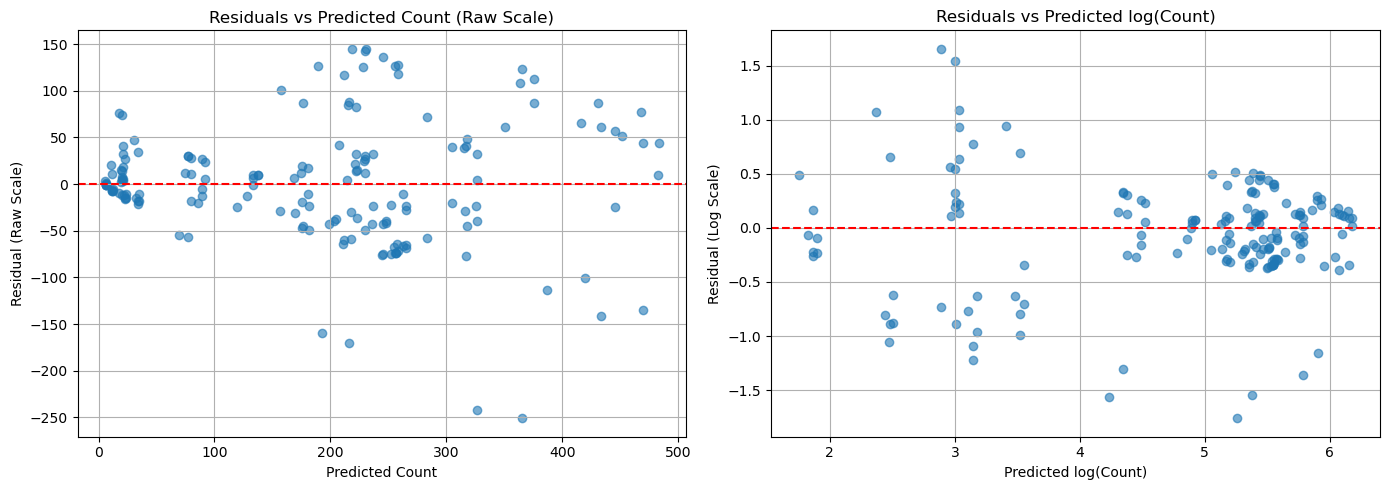

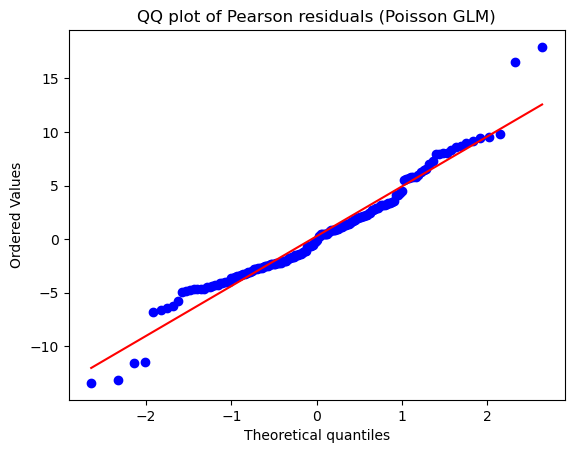

In [ ]:
# Pull aligned true values and predicted values
y_true = avg_counts_df['cnt'].values
y_pred = avg_counts_df['poisson_mean'].values

# Log-transform
y_true_log = np.log(y_true + 1e-8)
y_pred_log = np.log(y_pred + 1e-8)

# Residuals
residuals_raw = y_true - y_pred
residuals = y_true_log - y_pred_log

# Pearson residuals for Poisson regression
pearson_residuals = (y_true - y_pred) / np.sqrt(y_pred + 1e-8)
# pearson_residuals = (y_true_log - y_pred_log) / np.sqrt(y_pred + 1e-8)

# Metrics
mse_log = mean_squared_error(y_true_log, y_pred_log)
r2_log = r2_score(y_true_log, y_pred_log)
mse_raw = mean_squared_error(y_true, y_pred)
r2_raw = r2_score(y_true, y_pred)

print(f"MSE: {mse_log:.4f}, R²: {r2_log:.4f}")
print(f"Raw MSE: {mse_raw:.2f}, Raw R²: {r2_raw:.4f}")

# Residual plots
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

axs[0].scatter(y_pred, residuals_raw, alpha=0.6)
axs[0].axhline(0, color='red', linestyle='--')
axs[0].set_title("Residuals vs Predicted Count (Raw Scale)")
axs[0].set_xlabel("Predicted Count")
axs[0].set_ylabel("Residual (Raw Scale)")
axs[0].grid(True)

axs[1].scatter(y_pred_log, residuals, alpha=0.6)
axs[1].axhline(0, color='red', linestyle='--')
axs[1].set_title("Residuals vs Predicted log(Count)")
axs[1].set_xlabel("Predicted log(Count)")
axs[1].set_ylabel("Residual (Log Scale)")
axs[1].grid(True)

plt.tight_layout()
plt.show()


stats.probplot(pearson_residuals, dist="norm", plot=plt)
plt.title("QQ plot of Pearson residuals (Poisson GLM)")
plt.show()


# Extending Poisson Regression on (hour,day)

## Effect of workingday feature, one-hot encoded

In [27]:
X = df[[ 'hr', 'weekday', 'workingday']]
y = df['cnt']

X_onehot = pd.get_dummies(X, columns=['hr', 'weekday', 'workingday'], drop_first=True, dtype=float)

# build 'training' sets
X_train = torch.tensor(X_onehot.values, dtype=torch.float32)
y_train = torch.tensor(y.values, dtype=torch.float32).view(-1, 1)

In [28]:
input_dim = X_onehot.shape[1]
model = AffineTransform(input_dim)
optimizer = optim.SGD(model.parameters(), lr=1e-4)
loss_function = nn.PoissonNLLLoss(log_input=True)
# loss_function = poisson_nll_loss

n_epochs = int(2e3)
for epoch in range(n_epochs):
    model.train()
    optimizer.zero_grad()
    log_pred_rate = model(X_train)
    pred_rate = torch.exp(log_pred_rate)
    loss = loss_function(log_pred_rate, y_train)
    loss.backward()
    optimizer.step()
    if epoch % 100 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")
        # print(f"\rEpoch {epoch}, Loss: {loss.item():.4f}", end='')

Epoch 0, Loss: 24.6960
Epoch 100, Loss: -532.4662
Epoch 200, Loss: -747.5729
Epoch 300, Loss: -771.7665
Epoch 400, Loss: -789.2472
Epoch 500, Loss: -802.3203
Epoch 600, Loss: -811.5350
Epoch 700, Loss: -817.9115
Epoch 800, Loss: -822.4818
Epoch 900, Loss: -825.9854
Epoch 1000, Loss: -828.8486
Epoch 1100, Loss: -831.2900
Epoch 1200, Loss: -833.4205
Epoch 1300, Loss: -835.3015
Epoch 1400, Loss: -836.9713
Epoch 1500, Loss: -838.4582
Epoch 1600, Loss: -839.7845
Epoch 1700, Loss: -840.9691
Epoch 1800, Loss: -842.0280
Epoch 1900, Loss: -842.9754


In [29]:
## Predict the rates/mean for each (hour,day)
## Construct Hours_of_the_week dataframe to house the one-hot encoded labels
## Important: Hours_of_the_week and avg_counts_df should have the same ordering!!!

# ## Now each might have been a holiday at some point, so a non-workingday
# ## Let's predict regular day rates - weekdays are workingday=0, weekends are workinday=1

Hours_of_the_week = avg_counts_df[['hr', 'weekday']].copy()
Hours_of_the_week['workingday'] = Hours_of_the_week['weekday'].apply(lambda x: 1 if x in [0, 6] else 0)
Hours_of_the_week = pd.get_dummies(Hours_of_the_week, columns=['hr', 'weekday', 'workingday'], drop_first=True, dtype=float)
Hours_of_the_week = torch.tensor(Hours_of_the_week.values, dtype=torch.float32)

with torch.no_grad():
    log_preds = model(Hours_of_the_week).numpy().flatten()
    preds = np.exp(log_preds)

avg_counts_df['poisson_wd_mean'] = preds

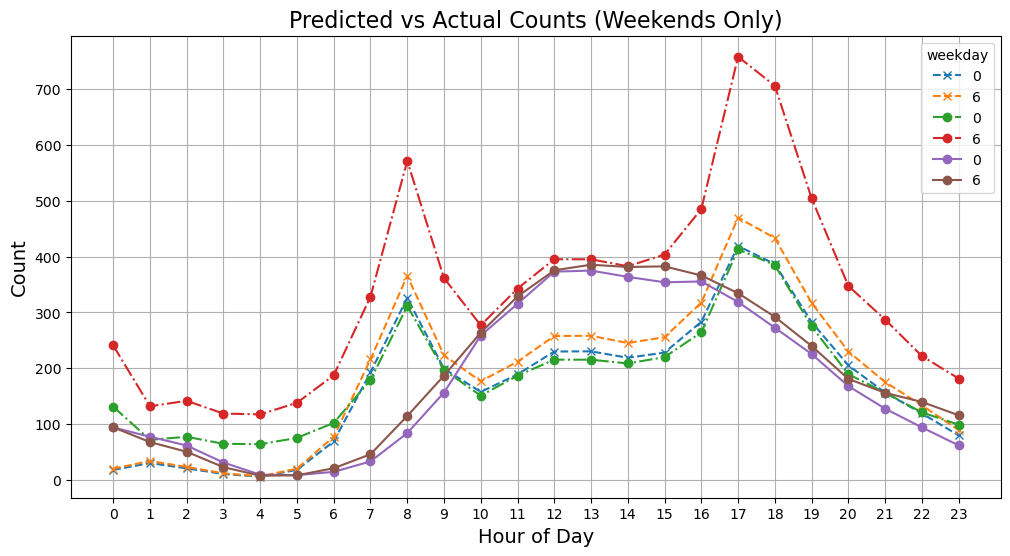

In [30]:
pivot_pred_before = avg_counts_df.pivot(index='hr', columns='weekday', values='poisson_mean')
pivot_pred_after = avg_counts_df.pivot(index='hr', columns='weekday', values='poisson_wd_mean')
pivot_actual = avg_counts_df.pivot(index='hr', columns='weekday', values='cnt')


# Filter pivot tables to only include Saturday (6) and Sunday (0)
pivot_pred_before_weekends = pivot_pred_before[[0, 6]]
pivot_pred_after_weekends = pivot_pred_after[[0, 6]]
pivot_actual_weekends = pivot_actual[[0, 6]]

fig, ax = plt.subplots(figsize=(12, 6))

# Plot predicted counts (dashed lines)
pivot_pred_before_weekends.plot(ax=ax, marker='x', linestyle='--')
pivot_pred_after_weekends.plot(ax=ax, marker='o', linestyle='-.')

# Plot actual counts (solid lines)
pivot_actual_weekends.plot(ax=ax, marker='o', linestyle='-')

ax.set_title('Predicted vs Actual Counts (Weekends Only)', fontsize=16)
ax.set_xlabel('Hour of Day', fontsize=14)
ax.set_ylabel('Count', fontsize=14)
ax.set_xticks(range(24))
ax.grid(True)
plt.show()

## Effect of interaction terms:

Here instead of doing a linear fit over one-hot encoded hours and days, we use only an interaction effect of the form $\beta_{ij}\,\text{hour}_i*\text{day}_j$. This way, the model will determine a rate for each (hour,day) combination.
$$
\begin{align}
    X &\sim \text{hour}_i \times \text{day}_j \\
    X^T \beta &= \sum_{i,j} \beta_{ij}\text{hour}_i \times \text{day}_j \\
    \lambda &= \exp X^T \beta
\end{align}
$$

In [31]:
X = df[[ 'hr', 'weekday']]
# we will use the original y:
y = df['cnt']

X_onehot = pd.get_dummies(X, columns=['hr', 'weekday'], drop_first=True, dtype=float)

# build 'training' sets
X_train = torch.tensor(X_onehot.values, dtype=torch.float32)
y_train = torch.tensor(y.values, dtype=torch.float32).view(-1, 1)

In [32]:
hr_cols = [col for col in X_onehot.columns if col.startswith('hr_')]
weekday_cols = [col for col in X_onehot.columns if col.startswith('weekday_')]

# Create interaction terms efficiently
interaction_cols = []
interaction_data = []

for h in hr_cols:
    for d in weekday_cols:
        interaction_cols.append(f'{h}__{d}')
        interaction_data.append(X_onehot[h].values * X_onehot[d].values)

# Create interaction DataFrame all at once
interaction_terms = pd.DataFrame(np.array(interaction_data).T, columns=interaction_cols, index=X_onehot.index)

# Combine with original features
X_full = pd.concat([X_onehot, interaction_terms], axis=1)

In [33]:
# Initialize and fit the Poisson regression model
model = PoissonRegressor(alpha=0.0, fit_intercept=False, max_iter=1000)
model.fit(X_full.to_numpy(), y.squeeze())

rates = []

for day in range(0, 7):
    if day == 0:
        day_one_hot = [0] * 6
    else:
        day_one_hot = [1 if i == day else 0 for i in range(1, 7)]

    daily_rates = []

    for hour in range(0, 24):
        if hour == 0:
            hour_one_hot = [0] * 23
        else:
            hour_one_hot = [1 if i == hour else 0 for i in range(1, 24)]

        # Compute interaction terms
        interaction = []
        for h in hour_one_hot:
            for d in day_one_hot:
                interaction.append(h * d)

        # Final feature vector
        feature = np.array(hour_one_hot + day_one_hot + interaction).reshape(1, -1)
        rate = model.predict(feature)
        daily_rates.append(rate.squeeze())

    rates.append(daily_rates)


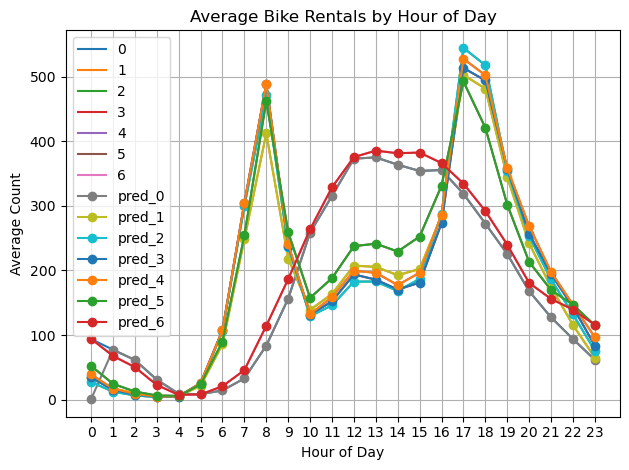

Samples: 17379, Parameters: 168, Ratio: 103.45


In [34]:
avg_count = df.groupby(['weekday','hr'])[['cnt']].mean().reset_index()
ax = avg_count.pivot(index='hr', columns='weekday', values='cnt').plot()

for i, daily_rates in enumerate(rates):
    plt.plot(range(24), daily_rates, marker='o', label = f'pred_{i}')

plt.xlabel('Hour of Day')
plt.ylabel('Average Count')
plt.title('Average Bike Rentals by Hour of Day')
plt.xticks(range(24))
plt.grid(True)
plt.tight_layout()
plt.legend()
plt.show()

total_params = model.coef_.size + 1
n_samples = X_full.shape[0]
print(f"Samples: {n_samples}, Parameters: {total_params}, Ratio: {n_samples/total_params:.2f}")

## Effect of a non-linear neural network model

In [35]:
X = df[[ 'hr', 'weekday']]
# we will use the original y:
y = df['cnt']

X_onehot = pd.get_dummies(X, columns=['hr', 'weekday'], drop_first=True, dtype=float)

# build 'training' sets
X_train = torch.tensor(X_onehot.values, dtype=torch.float32)
y_train = torch.tensor(y.values, dtype=torch.float32).view(-1, 1)

In [36]:

class NonLinearTransform(nn.Module):
    def __init__(self, input_dim):
        super(NonLinearTransform, self).__init__()
        self.hidden_size = 16
        self.linear1 = nn.Linear(input_dim, self.hidden_size)
        self.linear2 = nn.Linear(self.hidden_size, 1)

    def forward(self, x):
        x = F.relu(self.linear1(x))
        rate = torch.exp(self.linear2(x))
        return rate

input_dim = X_onehot.shape[1]
model = NonLinearTransform(input_dim)
optimizer = optim.Adam(model.parameters(), lr=0.01)
loss_function = nn.PoissonNLLLoss(log_input=False)

X_train = torch.tensor(X_onehot.values, dtype=torch.float32)
y_train = torch.tensor(y.values, dtype=torch.float32).view(-1, 1)

n_epochs = int(2*1e3)
for epoch in range(n_epochs):
    model.train()
    optimizer.zero_grad()
    pred_rate = model(X_train)
    loss = loss_function(pred_rate, y_train)
    loss.backward()
    optimizer.step()
    # if epoch % 100 == 0:
    #     print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

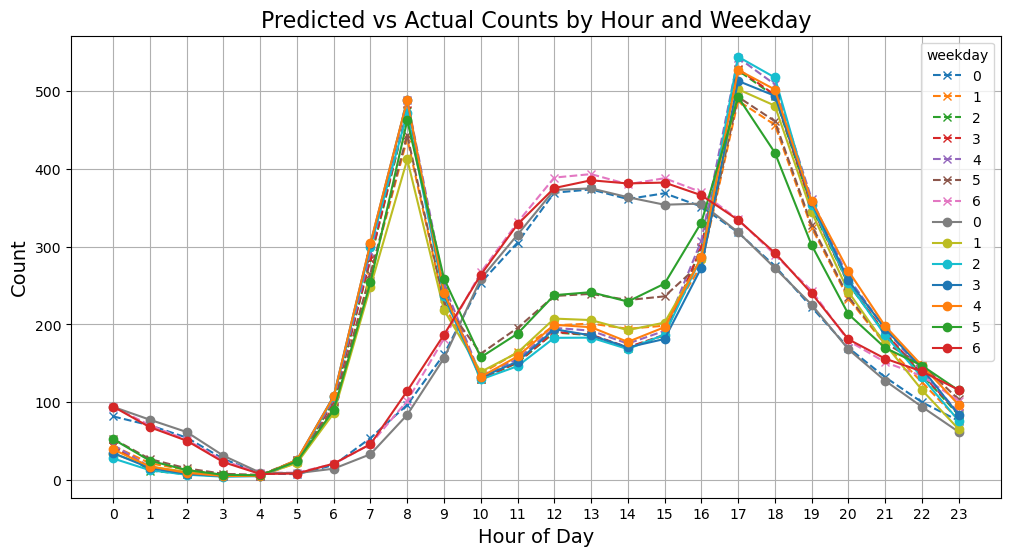

Samples: 17379, Parameters: 497, Ratio: 34.97


In [37]:
## Predict the rates/mean for each (hour,day)
## Construct Hours_of_the_week dataframe to house the one-hot encoded labels
## Important: Hours_of_the_week and avg_counts_df should have the same ordering!!!

Hours_of_the_week = avg_counts_df[['hr', 'weekday']]
Hours_of_the_week = pd.get_dummies(Hours_of_the_week, columns=['hr', 'weekday'], drop_first=True, dtype=float)
Hours_of_the_week = torch.tensor(Hours_of_the_week.values, dtype=torch.float32)

with torch.no_grad():
    preds = model(Hours_of_the_week).numpy().flatten()

avg_counts_df['nonlinear_poisson_mean'] = preds
#### Plot and Compare
pivot_pred = avg_counts_df.pivot(index='hr', columns='weekday', values='nonlinear_poisson_mean')
pivot_actual = avg_counts_df.pivot(index='hr', columns='weekday', values='cnt')


fig, ax = plt.subplots(figsize=(12,6))

# Plot predicted counts (dashed lines)
pivot_pred.plot(ax=ax, marker='x', linestyle='--')

# Plot actual counts (solid lines)
pivot_actual.plot(ax=ax, marker='o', linestyle='-')

ax.set_title('Predicted vs Actual Counts by Hour and Weekday', fontsize=16)
ax.set_xlabel('Hour of Day', fontsize=14)
ax.set_ylabel('Count', fontsize=14)
ax.set_xticks(range(24))
ax.grid(True)
# ax.legend(['Predicted', 'Actual'])
plt.show()

total_params = sum(p.numel() for p in model.parameters())
n_samples = X_train.shape[0]
print(f"Samples: {n_samples}, Parameters: {total_params}, Ratio: {n_samples/total_params:.2f}")

Log MSE: 0.2670, Log R²: 0.8457
Raw MSE: 4181.86, Raw R²: 0.7999


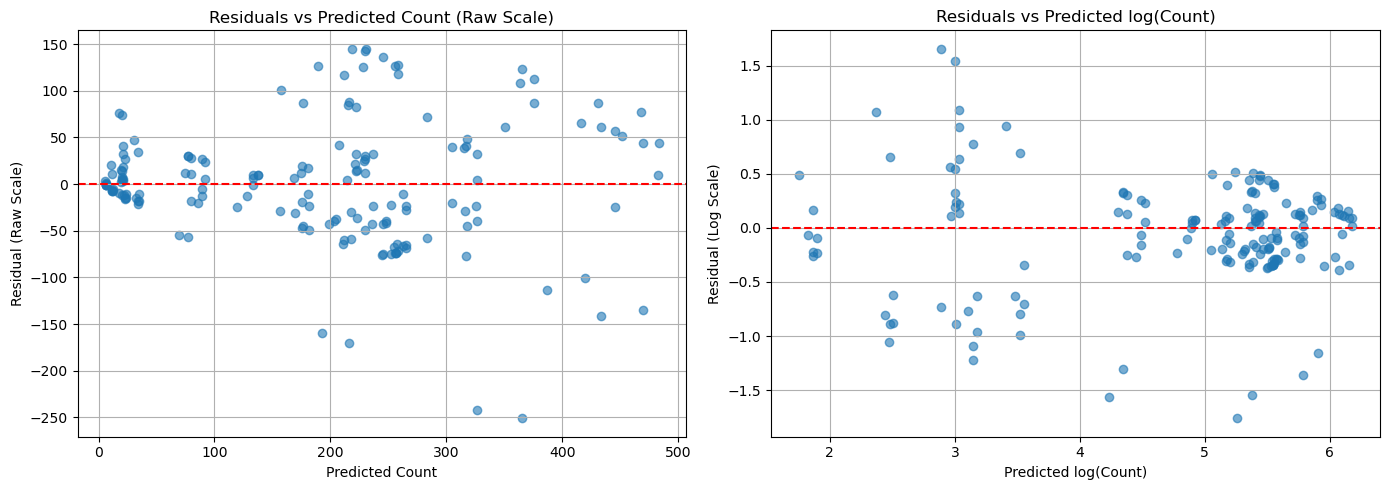

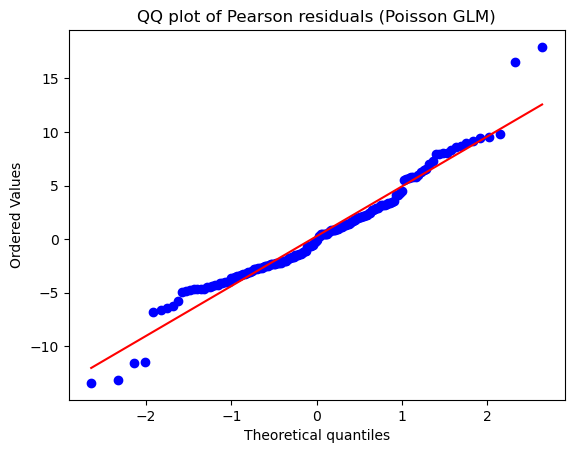

In [38]:
# Pull aligned true values and predicted values
y_true = avg_counts_df['cnt'].values
y_pred = avg_counts_df['poisson_mean'].values

# Log-transform
y_true_log = np.log(y_true + 1e-8)
y_pred_log = np.log(y_pred + 1e-8)

# Residuals
residuals_raw = y_true - y_pred
residuals = y_true_log - y_pred_log

# Pearson residuals for Poisson regression
pearson_residuals = (y_true - y_pred) / np.sqrt(y_pred + 1e-8)
# pearson_residuals = (y_true_log - y_pred_log) / np.sqrt(y_pred + 1e-8)

# Metrics
mse = mean_squared_error(y_true_log, y_pred_log)
r2 = r2_score(y_true_log, y_pred_log)
mse_raw = mean_squared_error(y_true, y_pred)
r2_raw = r2_score(y_true, y_pred)

print(f"Log MSE: {mse:.4f}, Log R²: {r2:.4f}")
print(f"Raw MSE: {mse_raw:.2f}, Raw R²: {r2_raw:.4f}")

# Residual plots
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

axs[0].scatter(y_pred, residuals_raw, alpha=0.6)
axs[0].axhline(0, color='red', linestyle='--')
axs[0].set_title("Residuals vs Predicted Count (Raw Scale)")
axs[0].set_xlabel("Predicted Count")
axs[0].set_ylabel("Residual (Raw Scale)")
axs[0].grid(True)

axs[1].scatter(y_pred_log, residuals, alpha=0.6)
axs[1].axhline(0, color='red', linestyle='--')
axs[1].set_title("Residuals vs Predicted log(Count)")
axs[1].set_xlabel("Predicted log(Count)")
axs[1].set_ylabel("Residual (Log Scale)")
axs[1].grid(True)

plt.tight_layout()
plt.show()


stats.probplot(pearson_residuals, dist="norm", plot=plt)
plt.title("QQ plot of Pearson residuals (Poisson GLM)")
plt.show()


# Bonus: A recurrent neural network Poisson regression model

1. Can we build a model with temporal correlations which competes with this!?
2. How to determine the appropriate residuals for this?

In [39]:

class PoissonRNN(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers=1):
        super(PoissonRNN, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        # Vanilla RNN
        self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True)
        
        # Fully connected layer to output Poisson rate parameter
        self.fc = nn.Linear(hidden_size, 1)
        
    def forward(self, x):
        # x shape: (batch_size, seq_len, input_size)
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size, device=x.device)
        
        out, _ = self.rnn(x, h0)  # out: (batch_size, seq_len, hidden_size)
        
        out = self.fc(out)         # (batch_size, seq_len, 1)
        
        rate = torch.exp(out)      # Ensure positive rate
        
        return rate

def poisson_nll_loss(pred_rate, target):
    # pred_rate, target: (batch, seq_len, 1)
    return torch.mean(pred_rate - target * torch.log(pred_rate + 1e-8))


In [40]:
input_dim = X_onehot.shape[1]
model = PoissonRNN(input_dim, hidden_size=4)
optimizer = optim.Adam(model.parameters(), lr=1e-2)
loss_function = nn.PoissonNLLLoss(log_input=False)

X_train = torch.tensor(X_onehot.values, dtype=torch.float32).unsqueeze(1)  # add seq_len dim
y_train = torch.tensor(y.values, dtype=torch.float32).view(-1, 1).unsqueeze(1)  # add seq_len and output dim

n_epochs = int(2e3)
for epoch in range(n_epochs):
    model.train()
    optimizer.zero_grad()
    
    pred_rate = model(X_train)  # shape: (batch_size, seq_len=1, 1)
    # loss = poisson_nll_loss(pred_rate, y_train)
    loss = loss_function(pred_rate, y_train)
    
    loss.backward()
    optimizer.step()
    
    # if epoch % 100 == 0:
    #     print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

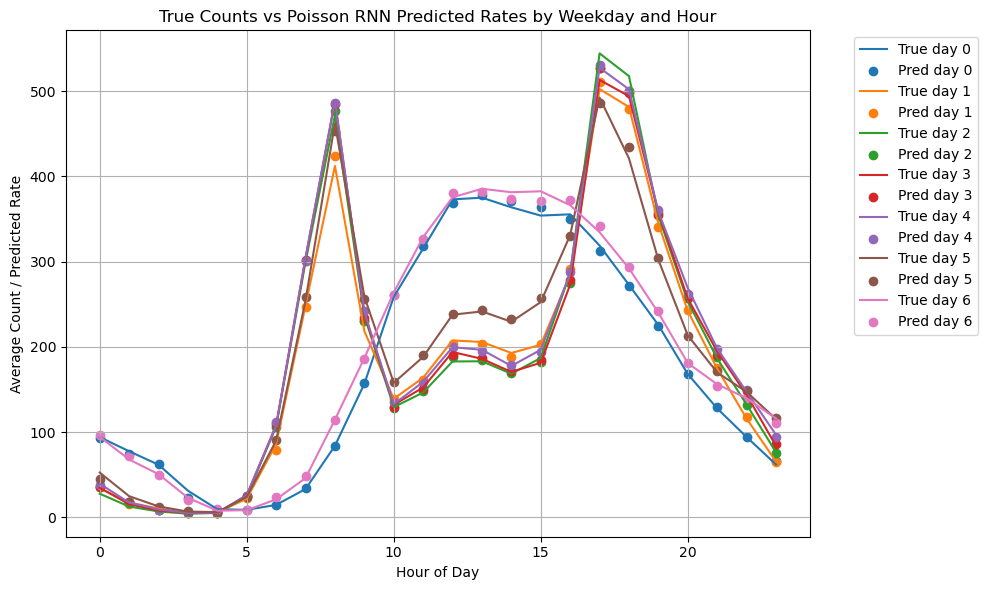

Samples: 17379, Parameters: 145, Ratio: 119.86


In [41]:
# Predict rates on entire data
model.eval()
with torch.no_grad():
    pred_rates = model(X_train).squeeze(-1).squeeze(-1).numpy()  # shape: (num_samples,)

df['pred_rate'] = pred_rates

# Group by weekday, hr and average counts & predictions
avg_counts = df.groupby(['weekday', 'hr'])['cnt'].mean().unstack()
avg_preds = df.groupby(['weekday', 'hr'])['pred_rate'].mean().unstack()

fig, ax = plt.subplots(figsize=(10,6))

for day in range(7):
    # True counts as solid lines
    ax.plot(avg_counts.columns, avg_counts.loc[day], label=f"True day {day}")
    
    # Predicted rates as dots (markers) only
    ax.scatter(avg_preds.columns, avg_preds.loc[day], label=f"Pred day {day}", marker='o')

ax.set_xlabel("Hour of Day")
ax.set_ylabel("Average Count / Predicted Rate")
ax.set_title("True Counts vs Poisson RNN Predicted Rates by Weekday and Hour")
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

total_params = sum(p.numel() for p in model.parameters())
n_samples = X_train.shape[0]
print(f"Samples: {n_samples}, Parameters: {total_params}, Ratio: {n_samples/total_params:.2f}")